# Part B — Email Spam Classification

## Dataset: `emails.csv`

This notebook implements the email classification experiment using the **provided dataset**.

The supplied dataset contains:
- 5,172 email records
- `Email No.` — email identifier
- 3,000 numerical word-based features
- `Prediction` — target label (`0` = non-spam, `1` = spam)

### Important dataset limitation

The provided file does **not contain the original email message text**. It already contains a numerical feature representation.

Therefore, CountVectorizer and TF-IDF cannot be independently fitted to this file because both require raw text. We use the supplied 3,000-dimensional representation directly and clearly document this limitation rather than creating artificial text.

This keeps the experiment reproducible and faithful to the supplied dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 20)


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv")

print("Path to dataset files:", path)

c:\Users\rutup\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\rutup\.cache\kagglehub\datasets\balaka18\email-spam-classification-dataset-csv\versions\1


In [3]:
# Load the supplied dataset

DATASET_FILE = path + "\\emails.csv"

email_df = pd.read_csv(DATASET_FILE)

print("Dataset shape:", email_df.shape)
print("Number of columns:", len(email_df.columns))
display(email_df.head())


Dataset shape: (5172, 3002)
Number of columns: 3002


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [4]:
# Inspect the dataset structure

print("Columns:")
print(email_df.columns.tolist())

print("\nData types:")
print(email_df.dtypes.value_counts())

print("\nMissing values:")
print(email_df.isnull().sum().sum())

print("\nDuplicate rows:", email_df.duplicated().sum())


Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 

In [5]:
# Inspect the target distribution

print("Prediction value counts:")
print(email_df["Prediction"].value_counts())

print("\nPrediction percentages:")
print((email_df["Prediction"].value_counts(normalize=True) * 100).round(2))


Prediction value counts:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentages:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


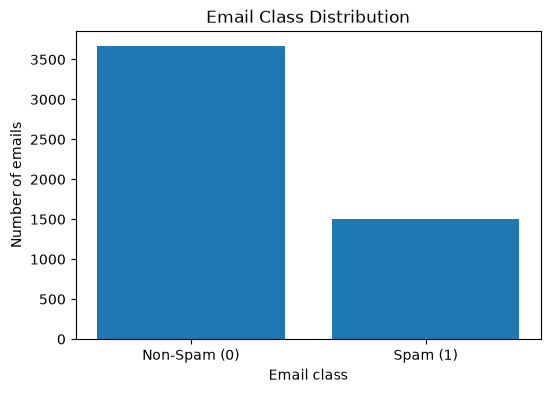

In [6]:
# Visualize spam/non-spam distribution

class_counts = email_df["Prediction"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-Spam (0)", "Spam (1)"], class_counts.values)
plt.xlabel("Email class")
plt.ylabel("Number of emails")
plt.title("Email Class Distribution")
plt.show()


## Preparing the feature matrix

`Email No.` is only an identifier and is excluded.

`Prediction` is the target.

All remaining columns are the supplied numerical word features.


In [7]:
# Separate features and target

X = email_df.drop(columns=["Email No.", "Prediction"])
y = email_df["Prediction"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target classes:", sorted(y.unique()))


Number of samples: 5172
Number of features: 3000
Target classes: [np.int64(0), np.int64(1)]


In [8]:
# Check the feature representation

print("Feature matrix shape:", X.shape)
print("\nFeature value range:")
print("Minimum:", X.min().min())
print("Maximum:", X.max().max())

print("\nFirst five feature rows:")
display(X.head())


Feature matrix shape: (5172, 3000)

Feature value range:
Minimum: 0
Maximum: 2327

First five feature rows:


,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0


In [9]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])


Training samples: 4137
Testing samples: 1035
Training features: 3000


## Logistic Regression

Logistic Regression is used as the traditional machine-learning classifier.

Training time measures the time required by `.fit()`.
Prediction time measures the time required by `.predict()`.


In [10]:
model = LogisticRegression(max_iter=1000)

start_time = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - start_time

start_time = time.perf_counter()
y_pred = model.predict(X_test)
prediction_time = time.perf_counter() - start_time

print("Training completed.")
print(f"Training time: {training_time:.6f} seconds")
print(f"Prediction time: {prediction_time:.6f} seconds")


Training completed.
Training time: 6.364624 seconds
Prediction time: 0.126259 seconds


In [11]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

results = pd.DataFrame({
    "Representation": ["Provided 3000-feature representation"],
    "Number of Features": [X.shape[1]],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "Training Time (s)": [training_time],
    "Prediction Time (s)": [prediction_time]
})

display(results.round(4))


,Representation,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Provided 3000-feature representation,3000,0.9826,0.9578,0.9833,0.9704,6.3646,0.1263


Confusion Matrix:
[[722  13]
 [  5 295]]


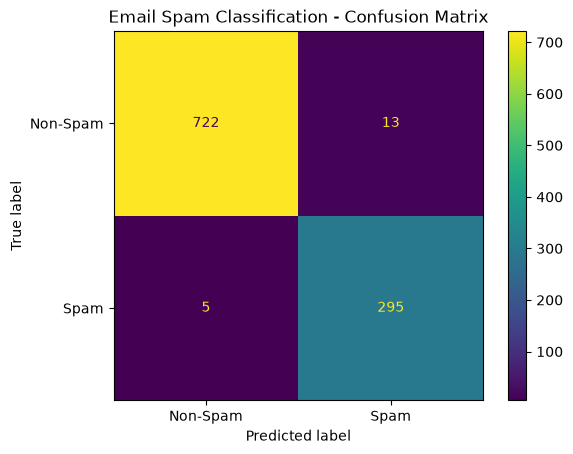

In [12]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam", "Spam"]
)

disp.plot()
plt.title("Email Spam Classification - Confusion Matrix")
plt.show()


## Interpreting the confusion matrix

For the binary classification task:

- **True Negative (TN):** non-spam correctly classified as non-spam
- **False Positive (FP):** non-spam incorrectly classified as spam
- **False Negative (FN):** spam incorrectly classified as non-spam
- **True Positive (TP):** spam correctly classified as spam

Precision focuses on how many predicted spam emails were actually spam.

Recall focuses on how many actual spam emails were detected.

F1 score balances precision and recall.


In [13]:
# Extract confusion-matrix values

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 722
False Positives: 13
False Negatives: 5
True Positives : 295


## CountVectorizer and TF-IDF requirement

The assignment asks for CountVectorizer and TF-IDF Vectorizer.

However, the supplied `emails.csv` contains **no raw email/message column**. Its 3,000 columns are already numerical word features.

CountVectorizer and TF-IDF require the original text to learn a vocabulary and construct a text-document matrix. Applying them to these already numerical features would therefore not be a valid implementation of the requested text-vectorization experiment.

Consequently, this notebook reports the supplied representation directly and documents the limitation instead of fabricating an email text column.


In [14]:
# Verify that no raw text column is available

text_like_columns = [
    col for col in email_df.columns
    if email_df[col].dtype == "object"
]

print("Object/string columns:", text_like_columns)

if not text_like_columns:
    print(
        "\nNo raw text column is present. "
        "The dataset is already numerically represented."
    )


Object/string columns: []

No raw text column is present. The dataset is already numerically represented.


## Representation and computation summary

The supplied representation has **3,000 numerical features per email**.

Advantages:
- Ready for traditional ML models
- No additional text preprocessing is required
- No vocabulary construction is required
- Computationally straightforward

Limitation:
- The original email text is unavailable, so new CountVectorizer and TF-IDF representations cannot be generated from this file.

If the original raw-email dataset becomes available, the CountVectorizer and TF-IDF experiments can be added without changing the classification/evaluation structure.


In [15]:
# Final summary table

summary = pd.DataFrame({
    "Item": [
        "Number of emails",
        "Number of supplied features",
        "Non-spam emails",
        "Spam emails",
        "Train/test split",
        "Classifier"
    ],
    "Value": [
        len(email_df),
        X.shape[1],
        int((y == 0).sum()),
        int((y == 1).sum()),
        "80% / 20%",
        "Logistic Regression"
    ]
})

display(summary)


,Item,Value
0,Number of emails,5172
1,Number of supplied features,3000
2,Non-spam emails,3672
3,Spam emails,1500
4,Train/test split,80% / 20%
5,Classifier,Logistic Regression


## Key observations

1. The dataset contains 5,172 email records and 3,000 supplied numerical features.
2. `Email No.` is excluded because it is an identifier rather than a predictive feature.
3. The target is `Prediction`, where 0 represents non-spam and 1 represents spam.
4. Logistic Regression is trained using an 80/20 stratified train-test split.
5. Accuracy, precision, recall, F1 score, confusion matrix, training time, and prediction time are reported.
6. CountVectorizer and TF-IDF cannot be independently applied because the supplied file does not contain raw email text.
7. The limitation is explicitly documented so the experiment remains reproducible and technically valid.


## Reproducibility

- Dataset file: `emails.csv`
- Random state: `42`
- Test size: `20%`
- Class split: stratified
- Classifier: Logistic Regression
- Maximum iterations: `1000`

Place `emails.csv` in the same directory as this notebook before running it.
